<a id="innhold"></a>

# GNSS Multipath Analysis – bruk av biblioteket direkte

Denne notebooken viser hvordan `gnssmultipath` kan brukes som et vanlig Python-bibliotek, uten å kjøre
hele multipath-analysen: lese RINEX-observasjoner, interpolere satellittkoordinater fra både
kringkastede efemerider og presise baner (SP3), og til slutt visualisere resultatet.

## Innhold

**1. [RINEX observasjonsfiler](#rinex-obs)**
- [1.1 Hente ut data](#hente-ut-data)
- [1.2 Lage en pandas DataFrame](#dataframe)
  - [Kun GPS](#kun-gps)
  - [Alle systemer og alle observasjonskoder i én tabell](#alle-koder)

**2. [Interpolasjon av satellittkoordinater](#satkoord)**
- [2.1 Kringkastede efemerider (navigasjonsfiler)](#broadcast)
  - [Interpoler efemeridene til observasjonsepokene](#interpoler-broadcast)
  - [Satellittkoordinatene som dictionary](#dict-format)
  - [Satellittkoordinatene som DataFrame](#df-format)
- [2.2 Presise satellittkoordinater (SP3-filer)](#sp3)
  - [Sammenligning med den kringkastede banen](#sammenligning)
  - [Toppene i Galileo-panelet: E14 og E18](#e14-e18)

**3. [Diverse](#diverse)**
- [3.1 Polarplot av systemene](#polarplot)
  - [Alle systemene i én figur](#alle-systemer)

Cellene er ment å kjøres i rekkefølge, siden senere seksjoner gjenbruker objekter fra de tidligere.
Unntaket er den siste cella i seksjon 3, som er selvstendig og kan kjøres alene.


<a id="rinex-obs"></a>

# 1. RINEX observasjonsfiler

`readRinexObs` leser observasjonsfila og returnerer et `RinexObsData`-objekt med observasjoner,
epoketider og headerinformasjon. Riktig leserutine (RINEX v2 eller v3/v4) velges automatisk ut fra
versjonsnummeret i fila.

[Tilbake til innholdsfortegnelsen](#innhold)


In [12]:
from pathlib import Path
import pandas as pd
from gnssmultipath import readRinexObs

pd.set_option('display.float_format', '{:,.3f}'.format)

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'TestData').is_dir())
rinObsFilename1 = repo_root / 'TestData' / 'ObservationFiles' / 'v3' / 'OPEC00NOR_S_20220010000_01D_30S_MO_3.04.rnx'

# Hele RinexObsData-objektet beholdes, slik at tid, header og posisjon kan gjenbrukes i seksjon 2
rinex = readRinexObs(rinObsFilename1)

# .observations gir det kodebaserte grensesnittet mot selve observasjonene
obs = rinex.observations


INFO(rinexReadObsFileHeader304): Rinex header has been read


Rinex observations are being read: 100%|██████████| (100/100)

INFO(readRinexObs304): The following GNSS systems have been read into the data: GPS, GLONASS, Galileo, Beidou
INFO(readRinexObs304): The following GPS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2W, L2W, D2W, S2W, C2X, L2X, D2X, S2X, C5X, L5X, D5X, S5X
INFO(readRinexObs304): The following GLONASS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2C, L2C, D2C, S2C, C2P, L2P, D2P, S2P
INFO(readRinexObs304): The following Galileo observation types have been registered: C1X, L1X, D1X, S1X, C5X, L5X, D5X, S5X, C7X, L7X, D7X, S7X, C8X, L8X, D8X, S8X
INFO(readRinexObs304): The following Beidou observation types have been registered: C2X, L2X, D2X, S2X, C6X, L6X, D6X, S6X, C7X, L7X, D7X, S7X
INFO(readRinexObs304): LLI have been read (if present in observation file)
INFO(readRinexObs304): SS have been read (if present in observation file)
INFO(readRinexObs304): Total processing time: 1.250000 seconds




<a id="hente-ut-data"></a>

## 1.1 Hente ut data

Eksempler på hvordan man kan hente ut data for hvert system, samt hvordan man henter enkeltsignaler,
frekvenser, bølgelengder osv.


In [13]:
# Hent observasjoner for hver GNSS-konstellasjon
gps = obs["G"]
galileo = obs["E"]
glonass = obs["R"]
beidou = obs["C"]

# Hent ut frekvensene for de to første GPS-båndene (L1 og L2) for å kunne lage ionosfærefrie lineærkombinasjoner
f1 = gps.frequency('C1C')
f2 = gps.frequency('C2W')

# Hente ut bølgelengdene for de to første GPS-båndene (L1 og L2)
gps_lambda1 = gps.wavelength('L1C')
gps_lambda2 = gps.wavelength('L2W')


# Pseudoranges i meter, faseobservasjonene konvertert fra bølgelengder til meter
C1C = gps.get('C1C')
C2W = gps.get('C2W')
L1C = gps.get('L1C') * gps_lambda1
L2W = gps.get('L2W') * gps_lambda2


# Ionosfære-fri kodemålinger
P_IF = (f1**2 * C1C - f2**2 * C2W) / (f1**2 - f2**2)

# Ionosfære-fri faseobservasjoner
L_IF = (f1**2 * L1C - f2**2 * L2W) / (f1**2 - f2**2)



<a id="dataframe"></a>

## 1.2 Lage en pandas DataFrame med de signalene man ønsker

Lett å se på de aktuelle signalene, samt skrive til en CSV-fil om ønskelig.


<a id="kun-gps"></a>

### Kun GPS


In [14]:
CODES = ['C1C', 'C2W', 'L1C', 'L2W']

# Én rad per satellitt og epoke. Raden beholdes så lenge minst én av kodene
# har en verdi; manglende enkeltsignaler blir NaN i sin egen kolonne.
# Bruk gps.to_dataframe(codes=CODES, dropna=False) for det fulle rutenettet.
# 'sv' er nullpaddet (G01..G32) og sorterer derfor likt som PRN.
# Ved flere systemer i samme tabell må 'system' også inn i indeksen.
df_gps = (gps.to_dataframe(codes=CODES)
           .pivot(index=['sv', 'datetime'], columns='code', values='value')[CODES]
           .reset_index()
           .rename_axis(columns=None))  # fjerner 'code' som navn på kolonneaksen

df_gps.to_csv('gps_observations.csv', index=False)
df_gps.head(3)


,sv,datetime,C1C,C2W,L1C,L2W
0,G01,2022-01-01 00:00:00,"24,615,547.102","24,615,553.594","129,355,653.645","100,796,591.338"
1,G01,2022-01-01 00:00:30,"24,593,524.070","24,593,531.090","129,239,926.161","100,706,414.042"
2,G01,2022-01-01 00:01:00,"24,571,517.500","24,571,523.656","129,124,275.943","100,616,297.020"


<a id="alle-koder"></a>

### Alle systemer og alle observasjonskoder i én tabell

Utelater man `systems` og `codes`, tas alle konstellasjoner og alle koder i fila med.
Kolonnesettet blir da unionen av kodene på tvers av systemene, så en kode som bare
finnes i ett system (f.eks. `C2W` for GPS) blir NaN for de øvrige.

[Tilbake til innholdsfortegnelsen](#innhold)


In [15]:
for sys_code in obs.systems:
    print(f"{obs[sys_code].system_name:9s} ({sys_code}): {obs[sys_code].codes}")

# Uten codes/systems tas alt med. 'system' må være med i indeksen, siden
# PRN-numrene gjentas på tvers av konstellasjonene.
df_alle = (obs.to_dataframe()
             .pivot(index=['system', 'sv', 'datetime'], columns='code', values='value')
             .reset_index()
             .rename_axis(columns=None))

df_alle.to_csv('alle_observasjoner.csv', index=False)
df_alle.head(5)



GPS       (G): ['C1C', 'L1C', 'D1C', 'S1C', 'C1P', 'L1P', 'D1P', 'S1P', 'C2W', 'L2W', 'D2W', 'S2W', 'C2X', 'L2X', 'D2X', 'S2X', 'C5X', 'L5X', 'D5X', 'S5X']
GLONASS   (R): ['C1C', 'L1C', 'D1C', 'S1C', 'C1P', 'L1P', 'D1P', 'S1P', 'C2C', 'L2C', 'D2C', 'S2C', 'C2P', 'L2P', 'D2P', 'S2P']
Galileo   (E): ['C1X', 'L1X', 'D1X', 'S1X', 'C5X', 'L5X', 'D5X', 'S5X', 'C7X', 'L7X', 'D7X', 'S7X', 'C8X', 'L8X', 'D8X', 'S8X']
BeiDou    (C): ['C2X', 'L2X', 'D2X', 'S2X', 'C6X', 'L6X', 'D6X', 'S6X', 'C7X', 'L7X', 'D7X', 'S7X']


,system,sv,datetime,C1C,C1P,C1X,C2C,C2P,C2W,C2X,...,S1P,S1X,S2C,S2P,S2W,S2X,S5X,S6X,S7X,S8X
0,C,C05,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,"40,190,280.008",...,NaN,NaN,NaN,NaN,NaN,36.300,NaN,35.200,35.900,NaN
1,C,C05,2022-01-01 00:00:30,NaN,NaN,NaN,NaN,NaN,NaN,"40,190,271.812",...,NaN,NaN,NaN,NaN,NaN,36.400,NaN,35.500,36.500,NaN
2,C,C05,2022-01-01 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,"40,190,265.617",...,NaN,NaN,NaN,NaN,NaN,36.300,NaN,35.600,35.200,NaN
3,C,C05,2022-01-01 00:01:30,NaN,NaN,NaN,NaN,NaN,NaN,"40,190,259.141",...,NaN,NaN,NaN,NaN,NaN,35.900,NaN,35.400,35.900,NaN
4,C,C05,2022-01-01 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,"40,190,254.656",...,NaN,NaN,NaN,NaN,NaN,36.200,NaN,35.000,35.000,NaN


<a id="satkoord"></a>

# 2. Interpolasjon av satellittkoordinater

Satellittkoordinater i ECEF kan hentes fra to kilder, og begge interpoleres til observasjonsepokene:

| Kilde | Klasse | Nøyaktighet | Kommentar |
| --- | --- | --- | --- |
| Kringkastede efemerider (RINEX nav) | `SatelliteEphemerisToECEF` | ~1–2 m | Følger med signalet, tilgjengelig i sanntid |
| Presise baner (SP3) | `PreciseSatCoords` | ~2–5 cm | Lastes ned i etterkant (f.eks. fra CDDIS) |

Begge klassene gir samme datastruktur tilbake:

```python
{'G': {'position': {'1': array([[X, Y, Z], ...]), ...},
       'azimuth':   array([n_epoker, maks_PRN + 1]),
       'elevation': array([n_epoker, maks_PRN + 1])}, ...}
```



<a id="broadcast"></a>

## 2.1 Kringkastede efemerider (navigasjonsfiler)

Her leses navigasjonsfila inn med `RinexNav`, og `SatelliteEphemerisToECEF` konverterer de
kringkastede efemeridene til ECEF-koordinater og interpolerer dem til observasjonsepokene:

* GPS, Galileo og BeiDou: Kepler-elementene propageres til hver epoke (`Kepler2ECEF`).
* GLONASS: tilstandsvektoren integreres med 4. ordens Runge-Kutta (`GLOStateVec2ECEF`).



In [16]:
from pathlib import Path
import numpy as np
from gnssmultipath import readRinexObs, RinexNav, SatelliteEphemerisToECEF

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'TestData').is_dir())
rinObsFilename1 = repo_root / 'TestData' / 'ObservationFiles' / 'v3' / 'OPEC00NOR_S_20220010000_01D_30S_MO_3.04.rnx'
rinNavFilename = repo_root / 'TestData' / 'NavigationFiles' / 'v3' / 'BRDC00IGS_R_20220010000_01D_MN.rnx'

# Lese inn observasjonsfila
rinex = readRinexObs(rinObsFilename1)

# Lese inn navigasjonsfila. Dette gir et RinexNav-objekt med alle ephemeridene.
navdata = RinexNav.read_nav(str(rinNavFilename))

# Tilnærmet mottakerposisjon (ECEF) fra headeren i observasjonsfila
x_rec, y_rec, z_rec = rinex.approxPosition.flatten().astype(float)
print(f"Approx. posisjon (ECEF) fra RINEX header: X={x_rec:.3f}  Y={y_rec:.3f}  Z={z_rec:.3f}")


# Vis efemeridene som dataframes. .gps/.glonass/.galileo/.beidou gir en DataFrame med navngitte kolonner per system
print("DataFrame med GPS-efemerider:")
display(navdata.gps.head(3))
print("DataFrame med Glonass-efemerider:")
display(navdata.glonass.head(3))
print("DataFrame med Galileo-efemerider:")
display(navdata.galileo.head(3))
print("DataFrame med BeiDou-efemerider:")
display(navdata.beidou.head(3))


INFO(rinexReadObsFileHeader304): Rinex header has been read


Rinex observations are being read: 100%|██████████| (100/100)


INFO(readRinexObs304): The following GNSS systems have been read into the data: GPS, GLONASS, Galileo, Beidou
INFO(readRinexObs304): The following GPS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2W, L2W, D2W, S2W, C2X, L2X, D2X, S2X, C5X, L5X, D5X, S5X
INFO(readRinexObs304): The following GLONASS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2C, L2C, D2C, S2C, C2P, L2P, D2P, S2P
INFO(readRinexObs304): The following Galileo observation types have been registered: C1X, L1X, D1X, S1X, C5X, L5X, D5X, S5X, C7X, L7X, D7X, S7X, C8X, L8X, D8X, S8X
INFO(readRinexObs304): The following Beidou observation types have been registered: C2X, L2X, D2X, S2X, C6X, L6X, D6X, S6X, C7X, L7X, D7X, S7X
INFO(readRinexObs304): LLI have been read (if present in observation file)
INFO(readRinexObs304): SS have been read (if present in observation file)
INFO(readRinexObs304): Total processing time: 1.281250 seconds




Rinex navigation file is being read: 100%|██████████| (100/100)

Approx. posisjon (ECEF) fra RINEX header: X=3149785.965  Y=598260.882  Z=5495348.493
DataFrame med GPS-efemerider:


...

,PRN,Year,Month,Day,Hour,Minute,Second,TauN,GammaN,MessageFrameTime,...,X_acc,health,Y,Y_vel,Y_acc,freq_num,Z,Z_vel,Z_acc,age
0,R01,"2,021.000",12.000,31.000,23.000,45.000,0.000,0.000,-0.000,"516,600.000",...,0.000,0.000,"13,506.838",-0.263,-0.000,1.000,"1,988.297",3.550,0.000,0.000
1,R01,"2,022.000",1.000,1.000,0.000,15.000,0.000,0.000,-0.000,"518,400.000",...,0.000,0.000,"12,733.445",-0.556,-0.000,1.000,"8,218.796",3.328,0.000,0.000
2,R01,"2,022.000",1.000,1.000,0.000,45.000,0.000,0.000,-0.000,"520,200.000",...,0.000,0.000,"11,656.097",-0.600,-0.000,1.000,"13,813.434",2.848,0.000,0.000


DataFrame med Galileo-efemerider:


,PRN,Year,Month,Day,Hour,Minute,Second,af0,af1,af2,...,IDOT,Data_sources,GAL_week,Spare_1,SISA,SV_health,BGD_E5a_E1,BGD_E5b_E1,Transmission_time,Spare_2
0,E01,"2,021.000",12.000,31.000,23.000,30.000,0.000,-0.001,-0.000,0.000,...,-0.000,258.000,"2,190.000",3.120,0.000,0.000,0.000,"517,340.000",NaN,NaN
1,E01,"2,022.000",1.000,1.000,0.000,30.000,0.000,-0.001,-0.000,0.000,...,-0.000,258.000,"2,190.000",0.000,3.120,0.000,0.000,0.000,"520,950.000",NaN
2,E01,"2,022.000",1.000,1.000,1.000,0.000,0.000,-0.001,-0.000,0.000,...,-0.000,258.000,"2,190.000",0.000,3.120,0.000,0.000,0.000,"522,700.000",NaN


DataFrame med BeiDou-efemerider:


,PRN,Year,Month,Day,Hour,Minute,Second,af0,af1,af2,...,IDOT,Spare_1,BDT_week,Spare_2,SV_accuracy,SatH1,TGD1,TGD2,Transmission_time,AODC
0,C01,"2,022.000",1.000,1.000,0.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,834.000,2.000,0.000,-0.000,-0.000,"518,400.400",0.000,NaN
1,C01,"2,022.000",1.000,1.000,1.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,834.000,2.000,0.000,-0.000,-0.000,"522,000.400",0.000,NaN
2,C01,"2,022.000",1.000,1.000,2.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,834.000,2.000,0.000,-0.000,-0.000,"525,600.400",0.000,NaN


<a id="interpoler-broadcast"></a>

### Interpoler efemeridene til observasjonsepokene

`get_sat_ecef_coordinates` propagerer efemeridene til hver observasjonsepoke og gir
satellittkoordinatene i ECEF. Tida oppgis som time-of-week i sekunder, eller som gregoriansk tid
med `time_fmt='GREGORIAN'`.


<a id="dict-format"></a>

### Satellittkoordinatene som dictionary

Resultatet er en nøstet dictionary med tre nivåer:

```text
sat_coord
└── [systemkode]             # 'G', 'R', 'E', 'C'
    └── ['position']         # Nøkkel for posisjon
        └── [PRN]            # '1', '12' (uten nullpolstring)
            └──> np.ndarray  # shape: (n_epoker, 3)
```

* **systemkode** – `'G'`, `'R'`, `'E'` eller `'C'`
* **PRN** – satellittnummeret som streng *uten* nullpolstring: `'1'`, `'12'` (ikke `'01'`)
* **verdien** – kolonnene er X, Y og Z i meter, én rad per epoke. `None` for satellitter som ikke
  har efemerider i navigasjonsfila.

Koordinatene er rotert for jordrotasjonen i signalets gangtid, altså uttrykt i ECEF-rammen på
mottakstidspunktet. Det er derfor mottakerposisjonen må oppgis til konstruktøren.

Etter at `compute_satellite_azimut_and_elevation_angle` er kjørt, får hvert system også
nøklene `'azimuth'` og `'elevation'`.

```python
# Alle systemer og satellitter
sat_coord = converter.get_sat_ecef_coordinates(tow)
sat_coord['G']['position']['12']        # ECEF-koordinater for G12, shape (n_epoker, 3)
```


In [17]:
# 'navdata' er allerede lest inn over, så den gjenbrukes her i stedet for å lese fila på nytt.
converter = SatelliteEphemerisToECEF(navdata, x_rec, y_rec, z_rec, desired_systems=['G', 'R', 'E', 'C'])

# Henter observasjonsepokene gitt som [GPS-uke, time-of-week] fra rinex objektet
time_epochs, tow = rinex.time_epochs, rinex.time_epochs[:, 1]


# Interpoler til observasjonsepokene (time-of-week i sekunder)
sat_coord = converter.get_sat_ecef_coordinates(tow, output_format="dict") # Interploerte satellittkoordinater i ECEF for alle systemer og alle epoker.
# `converter.to_dataframe()` gir em DataFrame uten å regne på nytt.

# Dictinary med systemer som nøkler, og for hver systemnøkkel er det en dict med 'position' som nøkler. Hver av disse er en dict med satellitt-ID/PRN som nøkler, og for hver satellitt-ID er det en numpy array med koordinater for alle epoker.
sat_coord['G']["position"]["12"] # Interpolerte ECEF-koordinater for GPS-satellitt G12 for alle epoker. Dette er en numpy array med shape (N, 3), der N er antall epoker


Satellite coordinates are being computed for GLONASS, Galileo, GPS and BeiDou:100%|██████████|(123/123 satellites)


array([[-19460519.74560541,  10712227.67130098, -14713770.94282284],
       [-19515353.05250768,  10708515.65156447, -14642020.26873194],
       [-19569925.70011936,  10704891.13393806, -14569991.85785806],
       ...,
       [-19745975.05667562,  10691075.39186011, -14335353.19092044],
       [-19799430.83673856,  10687800.240529  , -14262165.24671777],
       [-19852619.82690825,  10684606.73207287, -14188706.62430574]],
      shape=(2880, 3))

<a id="df-format"></a>

### Satellittkoordinatene som DataFrame

Med `output_format='pd.DataFrame'` returneres koordinatene som en DataFrame med multiindeks
(`timestamp`, `system`, `SV`) i stedet for en dictionary, noe som gjør det enkelt å hente ut
enkeltsystemer eller enkeltsatellitter. `converter.to_dataframe()` gir det samme uten å regne på nytt.

Tida kan oppgis som `datetime64`, altså rett fra `rinex.datetimes`. Oppgir man time-of-week i stedet,
hentes GPS-uka fra efemeridene slik at tidsstemplene i indeksen blir riktige uansett.

[Tilbake til innholdsfortegnelsen](#innhold)


In [18]:
# Samme beregning, men med tidsstempler inn og DataFrame ut
df_sat_coord = converter.get_sat_ecef_coordinates(rinex.datetimes, output_format='pd.DataFrame')

# Hente bare Galileo-satellitter
df_galileo = df_sat_coord.xs('E', level='system')

# Hente en bestemt Galileo-satellitt (f.eks. E01)
df_galileo_e01 = df_sat_coord.xs(('E', 'E01'), level=('system', 'SV'))
display(df_galileo_e01.head(3))
display(df_galileo.head(3))

Satellite coordinates are being computed for GLONASS, Galileo, GPS and BeiDou:100%|██████████|(123/123 satellites)


,X,Y,Z
timestamp,,,
2022-01-01 00:00:00,"26,795,203.152","-10,996,113.227","6,147,095.221"
2022-01-01 00:00:30,"26,812,283.157","-11,003,483.598","6,058,821.142"
2022-01-01 00:01:00,"26,829,088.658","-11,010,829.276","5,970,464.151"


X               Y              Z
timestamp  SV                                                
2022-01-01 E01  26,795,203.152 -10,996,113.227  6,147,095.221
           E02 -26,702,925.935  11,077,309.099 -6,295,507.777
           E03 -16,828,074.926   6,499,744.077 23,460,115.757

<a id="sp3"></a>

## 2.2 Presise satellittkoordinater (SP3-filer)

SP3-filer inneholder ferdig beregnede satellittposisjoner i ECEF, typisk hvert 5. eller 15. minutt.
`PreciseSatCoords` leser fila (`SP3Reader`) og interpolerer posisjonene til observasjonsepokene med
Nevilles algoritme (`SP3Interpolator`, 7 punkter som standard).

Klassen tar imot enten et ferdig innlest `RinexObsData`-objekt, en sti til en observasjonsfil, eller
bare epokene (`time_epochs`) hvis man ikke har observasjoner. Mottakerposisjonen trengs ikke for å
interpolere banene, bare for azimut og elevasjon, og oppgis derfor til de metodene.


In [19]:
from gnssmultipath import PreciseSatCoords, SPEED_OF_LIGHT

sp3Filename = repo_root / 'TestData' / 'SP3' / 'Testfile_20220101.eph'

# 'rinex' er allerede lest inn, så observasjonsfila leses ikke på nytt.
# Flere SP3-filer kan også sendes inn som en liste, f.eks. for å dekke et døgnskille.
precise = PreciseSatCoords(sp3Filename, rinex_obs_file=rinex, GNSSsystems=['G', 'R', 'E', 'C'])

# Interpolerte koordinater som DataFrame med kolonnene Epoch, Satellite, X, Y, Z og Clock Bias
df_precise = precise.satcoords
df_precise.head()


Interpolating satellite coordinates: 100%|██████████| (113/113)


,Epoch,Satellite,X,Y,Z,Clock Bias
0,2022-01-01 00:00:00,G01,"13,882,271.938","-21,710,006.216","5,357,125.462",0.000
1,2022-01-01 00:00:30,G01,"13,879,359.404","-21,687,354.103","5,451,773.664",0.000
2,2022-01-01 00:01:00,G01,"13,876,340.016","-21,664,366.026","5,546,314.566",0.000
3,2022-01-01 00:01:30,G01,"13,873,215.266","-21,641,041.824","5,640,746.295",0.000
4,2022-01-01 00:02:00,G01,"13,869,986.647","-21,617,381.350","5,735,066.985",0.000


<a id="sammenligning"></a>

### Sammenligning med den kringkastede banen

Hvor mye bedre er egentlig den presise banen? Under sammenlignes alle satellitter som finnes i begge
løsningene, epoke for epoke.

Begge klassene gir koordinater i ECEF-rammen på mottakstidspunktet, altså rotert for jordrotasjonen i
signalets gangtid. SP3-koordinatene gjelder for selve epoken, og roteres derfor tilsvarende før
sammenligningen. Uten denne rotasjonen blir avviket 140–175 m, som er ren rammeforskjell og ikke
banefeil.

Forventet resultat er 1–3 m i middel, som er den reelle banefeilen i de kringkastede efemeridene.

<a id="e14-e18"></a>

#### Merk deg toppene i Galileo-panelet: E14 og E18

To Galileo-satellitter skiller seg tydelig ut, med enkelttopper på 48 m og 10 m mot typisk 1–2 m for
resten. Det er ikke en feil i beregningen, men to satellitter som faktisk er spesielle:

| SV | Eksentrisitet | Store halvakse | Perigeum | Apogeum | Maks avvik |
| --- | --- | --- | --- | --- | --- |
| E18 | 0,16397 | 27 978 km | 17 012 km | 26 187 km | 47,7 m |
| E14 | 0,16367 | 27 977 km | 17 020 km | 26 178 km | 10,1 m |
| E01 (normal) | 0,00029 | 29 600 km | 23 214 km | 23 231 km | 1,4 m |

E18 og E14 er **GSAT0201 «Doresa»** og **GSAT0202 «Milena»**, skutt opp 22. august 2014 med en Sojuz
der Fregat-overtrinnet sviktet og satte dem i feil bane. Etter delvis korreksjon ligger de igjen i
klart elliptiske baner: eksentrisiteten er over 500 ganger større enn for en normal Galileo, og høyden
varierer med rundt 9 000 km per omløp mot 17 km for de øvrige. De inngår ikke i den operative
konstellasjonen, og er i deler av dette datasettet merket med `SISA = 16.0`, altså
«no accuracy prediction available».

Selve toppene oppstår der navigasjonsfila har **hull i efemeride-serien**. Normalt kommer et nytt
datasett hvert 30. minutt, men for E18 finnes flere hull på 70–80 minutter, og toppen kl. 06:40:30
ligger midt i et slikt hull med en efemeride som er 2 370 s gammel. Sammenhengen er entydig:

| Efemeride-alder | Antall epoker | Middel | Maks |
| --- | --- | --- | --- |
| 0–900 s | 2243 | 1,17 m | 6,37 m |
| 900–1800 s | 464 | 3,01 m | 24,63 m |
| 1800–3600 s | 135 | 8,14 m | 47,66 m |

Kepler-modellen bruker **oskulerende baneelementer**, som bare er gyldige nær `Toe`. Ekstrapolerer man 40
minutter utover, vokser feilen — og for en bane med e = 0,16 beveger satellitten seg så mye raskere
nær perigeum at feilen vokser langt fortere enn for en tilnærmet sirkulær bane. Det er derfor nettopp
disse to satellittene får utslag, mens middelverdien for Galileo likevel er den laveste av alle fire
systemene.

[Tilbake til innholdsfortegnelsen](#innhold)


,mean,max
system,,
C,1.590,10.222
E,0.936,47.655
G,1.557,4.042
R,2.913,9.638


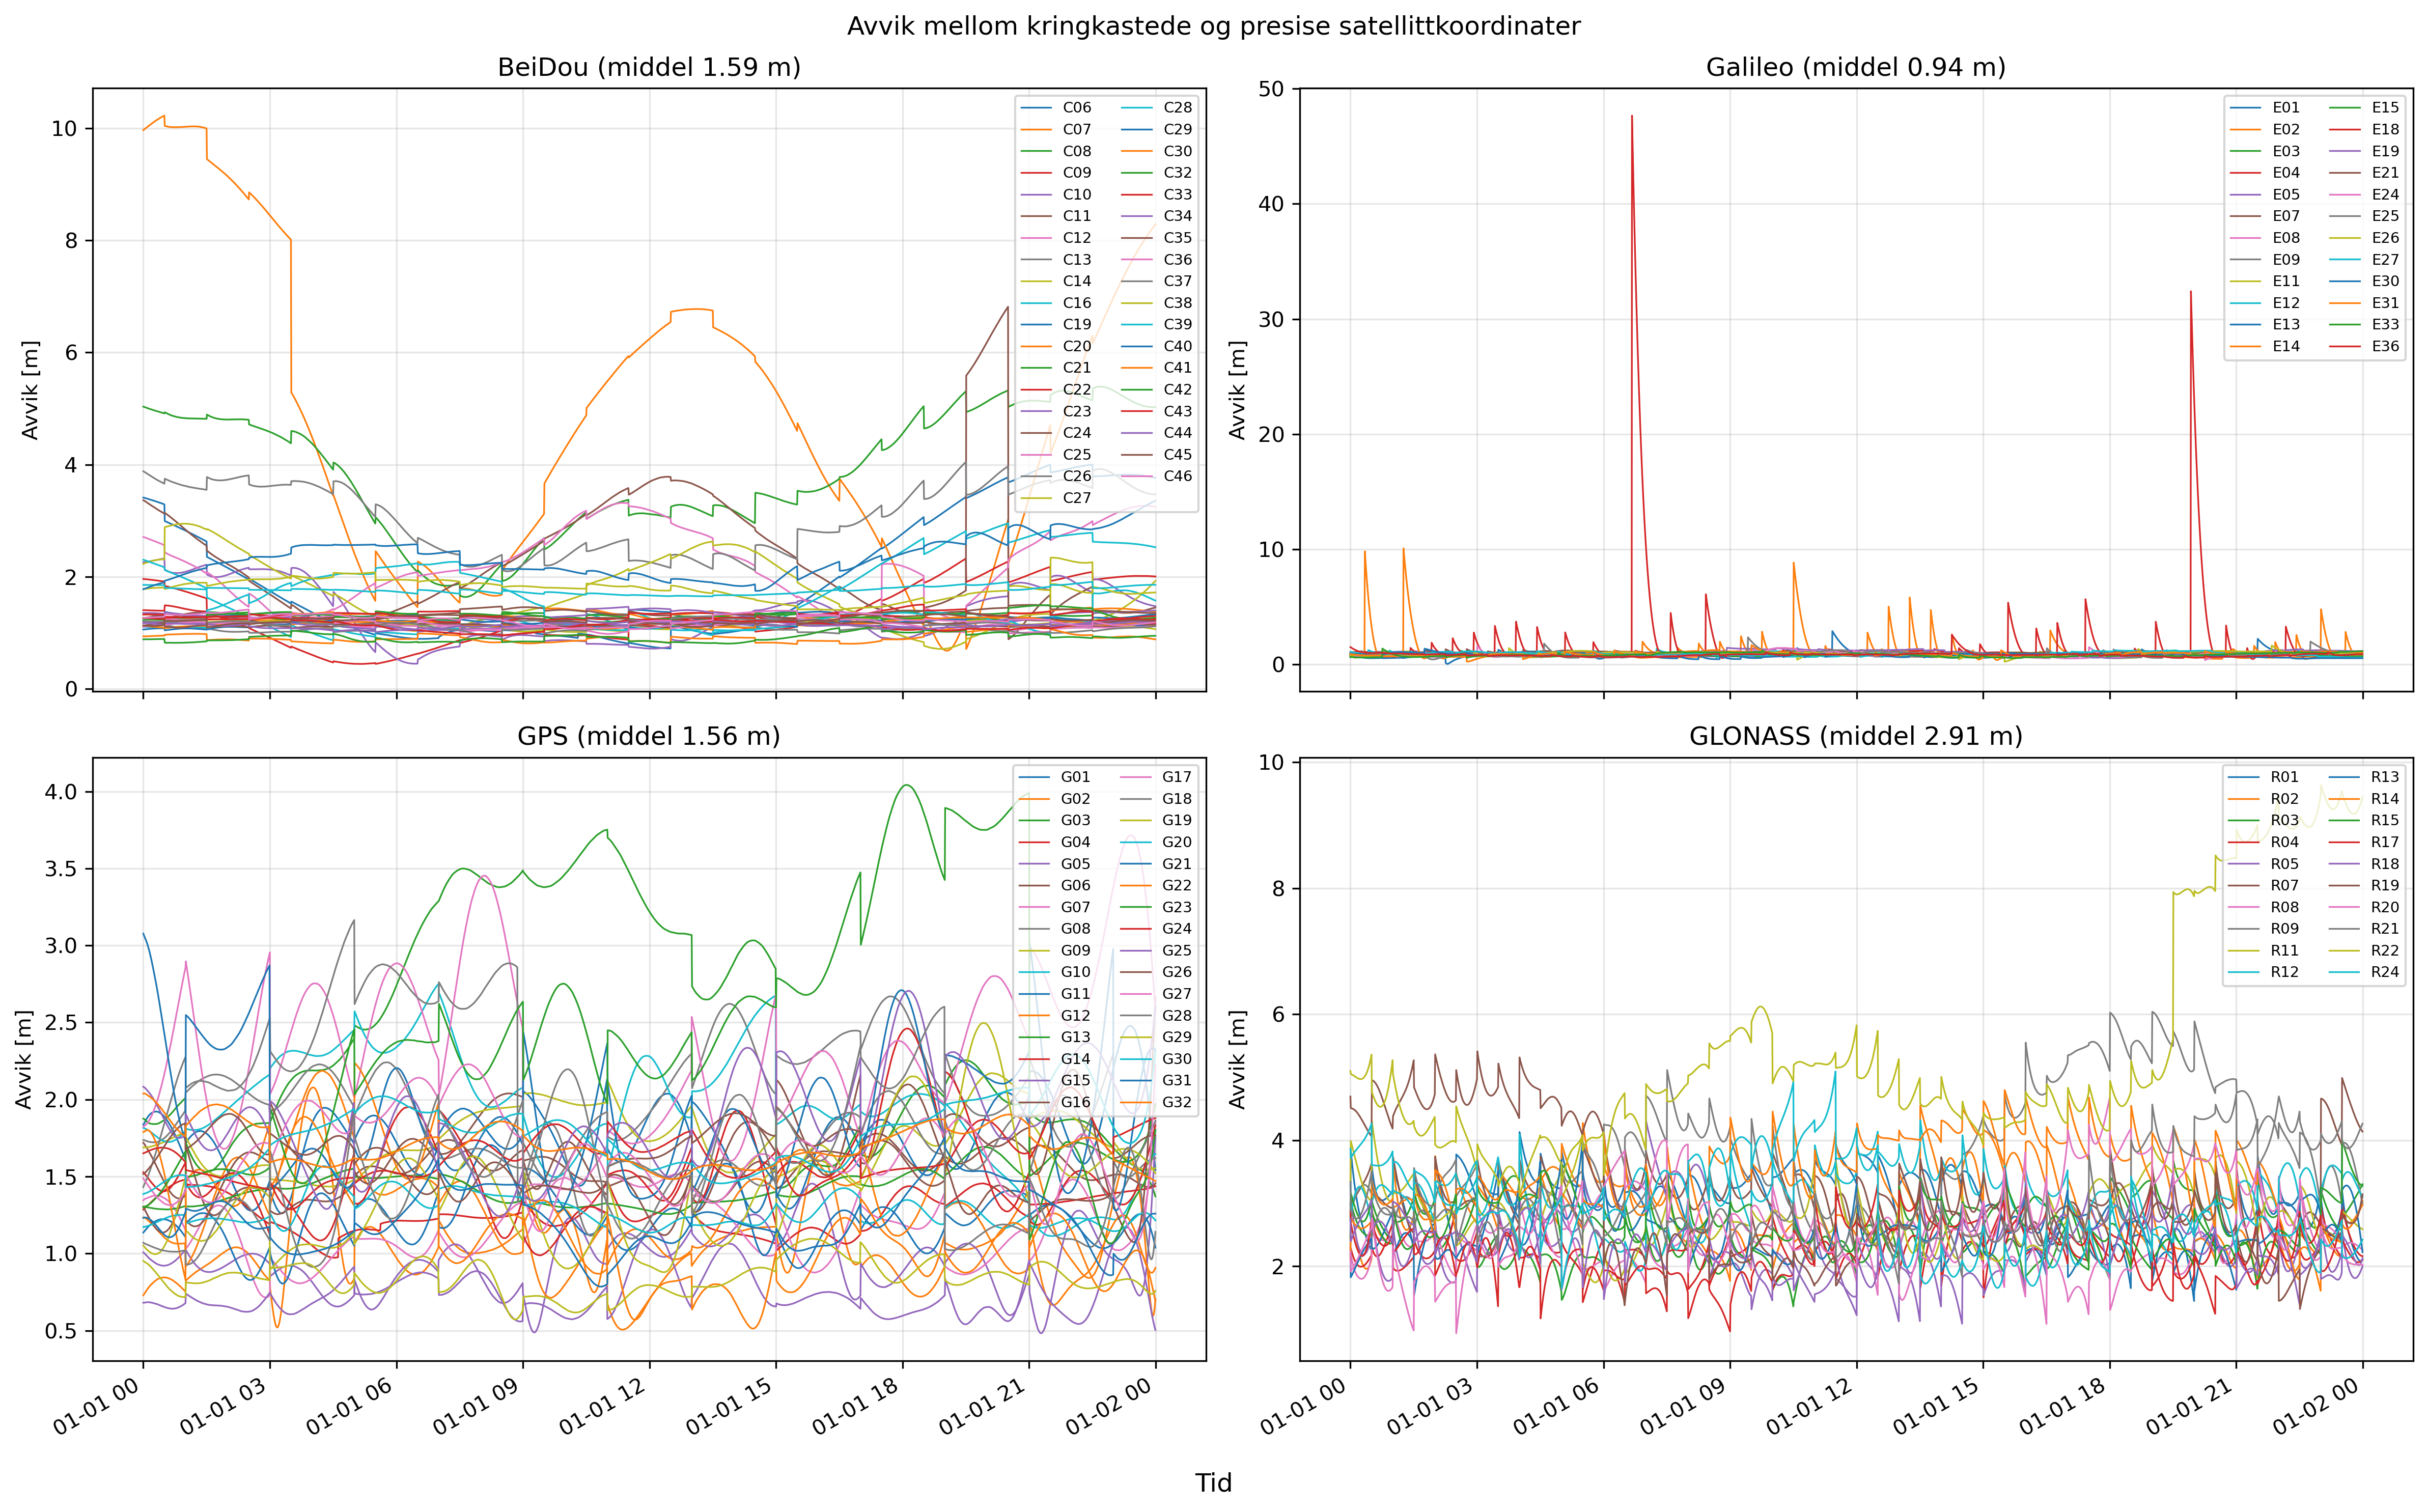

In [20]:
import matplotlib.pyplot as plt
from IPython.display import display
from gnssmultipath.constants import earth_rotation_rate
import pandas as pd

# Alle fire systemene returnerer nå koordinater i ECEF-rammen på mottakstidspunktet,
# så SP3-koordinatene roteres likt for alle.
receiver_position = np.array([x_rec, y_rec, z_rec])
diff_frames = []

for system, system_data in sat_coord.items():
    precise_system = df_precise[df_precise['Satellite'].str.startswith(system)]

    for prn, broadcast_xyz in system_data['position'].items():
        if broadcast_xyz is None:
            continue

        satellite = f'{system}{int(prn):02d}'
        precise_satellite = (precise_system[precise_system['Satellite'] == satellite]
                             .sort_values('Epoch'))
        if precise_satellite.empty:
            continue

        broadcast_xyz = np.asarray(broadcast_xyz, dtype=float)
        sp3_xyz = precise_satellite[['X', 'Y', 'Z']].to_numpy()
        if len(sp3_xyz) != len(broadcast_xyz):
            raise ValueError(f'{satellite}: broadcast og SP3 har ulikt antall epoker')

        travel_time = np.linalg.norm(sp3_xyz - receiver_position, axis=1) / SPEED_OF_LIGHT
        theta = earth_rotation_rate(system) * travel_time
        X_sp3, Y_sp3, Z_sp3 = sp3_xyz.T
        reference_xyz = np.column_stack([
            X_sp3 * np.cos(theta) + Y_sp3 * np.sin(theta),
            -X_sp3 * np.sin(theta) + Y_sp3 * np.cos(theta),
            Z_sp3,
        ])

        diff_frames.append(pd.DataFrame({
            'timestamp': pd.to_datetime(precise_satellite['Epoch']).to_numpy(),
            'system': system,
            'SV': satellite,
            'difference_m': np.linalg.norm(broadcast_xyz - reference_xyz, axis=1),
        }))

df_orbit_diff = (pd.concat(diff_frames, ignore_index=True)
                   .sort_values(['timestamp', 'system', 'SV'])
                   .reset_index(drop=True))

display(df_orbit_diff.groupby('system')['difference_m'].agg(['mean', 'max']).round(3))

# Plot hele tidsserien med ett panel per GNSS-system.
systems = sorted(df_orbit_diff['system'].unique())
system_names = {'G': 'GPS', 'R': 'GLONASS', 'E': 'Galileo', 'C': 'BeiDou'}
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()

for axis, system in zip(axes, systems):
    system_diff = df_orbit_diff[df_orbit_diff['system'] == system]
    for satellite, satellite_diff in system_diff.groupby('SV', sort=True):
        axis.plot(satellite_diff['timestamp'], satellite_diff['difference_m'],
                  linewidth=0.8, label=satellite)
    axis.set_title(f"{system_names.get(system, system)} "
                   f"(middel {system_diff['difference_m'].mean():,.2f} m)")
    axis.set_ylabel('Avvik [m]')
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=7, ncol=2, loc='upper right')

for axis in axes[len(systems):]:
    axis.set_visible(False)

fig.supxlabel('Tid')
fig.suptitle('Avvik mellom kringkastede og presise satellittkoordinater')
fig.autofmt_xdate()
fig.tight_layout()
image = BytesIO()
fig.savefig(image, format='png', dpi=300, bbox_inches='tight')
plt.close(fig)  
Image(data=image.getvalue(), width=1200)

<a id="diverse"></a>

# 3. Diverse

[Tilbake til innholdsfortegnelsen](#innhold)


<a id="polarplot"></a>

## 3.1 Polarplot av systemene

Azimut- og elevasjonsvinklene fra seksjon 2 kan sendes rett inn i `make_skyplot`.

<a id="alle-systemer"></a>

### Alle systemene i én figur

`make_skyplot` lager normalt sin egen figur, men med argumentet `ax` tegner den i stedet inn i en
akse du oppgir selv. Da er det nok å lage et rutenett med polare akser og kalle funksjonen én gang
per system:

```python
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': 'polar'})
polarplot.make_skyplot(azimuth, elevation, name, None, save=False, ax=axis)
```

Skrift, linjebredde og legend skaleres automatisk ned når `ax` er oppgitt, slik at plottene passer
i et rutenett. Lagring hoppes over, siden figuren tilhører den som kaller.

Forskjellene mellom konstellasjonene kommer tydelig fram på denne breddegraden (ca. 59,7° N): GPS,
Galileo og BeiDou har et tomt «hull» mot nord fordi baneinklinasjonen gjør at satellittene aldri
passerer rett over nordhorisonten, mens GLONASS med sin høyere inklinasjon på 64,8° dekker nord langt
bedre. BeiDou skiller seg ut med satellitter som står tilnærmet stille — det er GEO- og IGSO-banene.

Cella under er selvstendig: den leser inn filene og regner ut vinklene selv, så den kan kjøres uten
å ha kjørt seksjon 1 og 2 først.

[Tilbake til innholdsfortegnelsen](#innhold)


INFO(rinexReadObsFileHeader304): Rinex header has been read


Rinex observations are being read: 100%|██████████| (100/100)


INFO(readRinexObs304): The following GNSS systems have been read into the data: GPS, GLONASS, Galileo, Beidou
INFO(readRinexObs304): The following GPS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2W, L2W, D2W, S2W, C2X, L2X, D2X, S2X, C5X, L5X, D5X, S5X
INFO(readRinexObs304): The following GLONASS observation types have been registered: C1C, L1C, D1C, S1C, C1P, L1P, D1P, S1P, C2C, L2C, D2C, S2C, C2P, L2P, D2P, S2P
INFO(readRinexObs304): The following Galileo observation types have been registered: C1X, L1X, D1X, S1X, C5X, L5X, D5X, S5X, C7X, L7X, D7X, S7X, C8X, L8X, D8X, S8X
INFO(readRinexObs304): The following Beidou observation types have been registered: C2X, L2X, D2X, S2X, C6X, L6X, D6X, S6X, C7X, L7X, D7X, S7X
INFO(readRinexObs304): LLI have been read (if present in observation file)
INFO(readRinexObs304): SS have been read (if present in observation file)
INFO(readRinexObs304): Total processing time: 1.296875 seconds




Rinex navigation file is being read: 100%|██████████| (100/100)
Satellite coordinates are being computed for GLONASS, Galileo, GPS and BeiDou:100%|██████████|(123/123 satellites)
Satellite azimuth and elevation angles are being computed for GLONASS, Galileo, GPS and BeiDou:100%|██████████|(123/123 satellites)


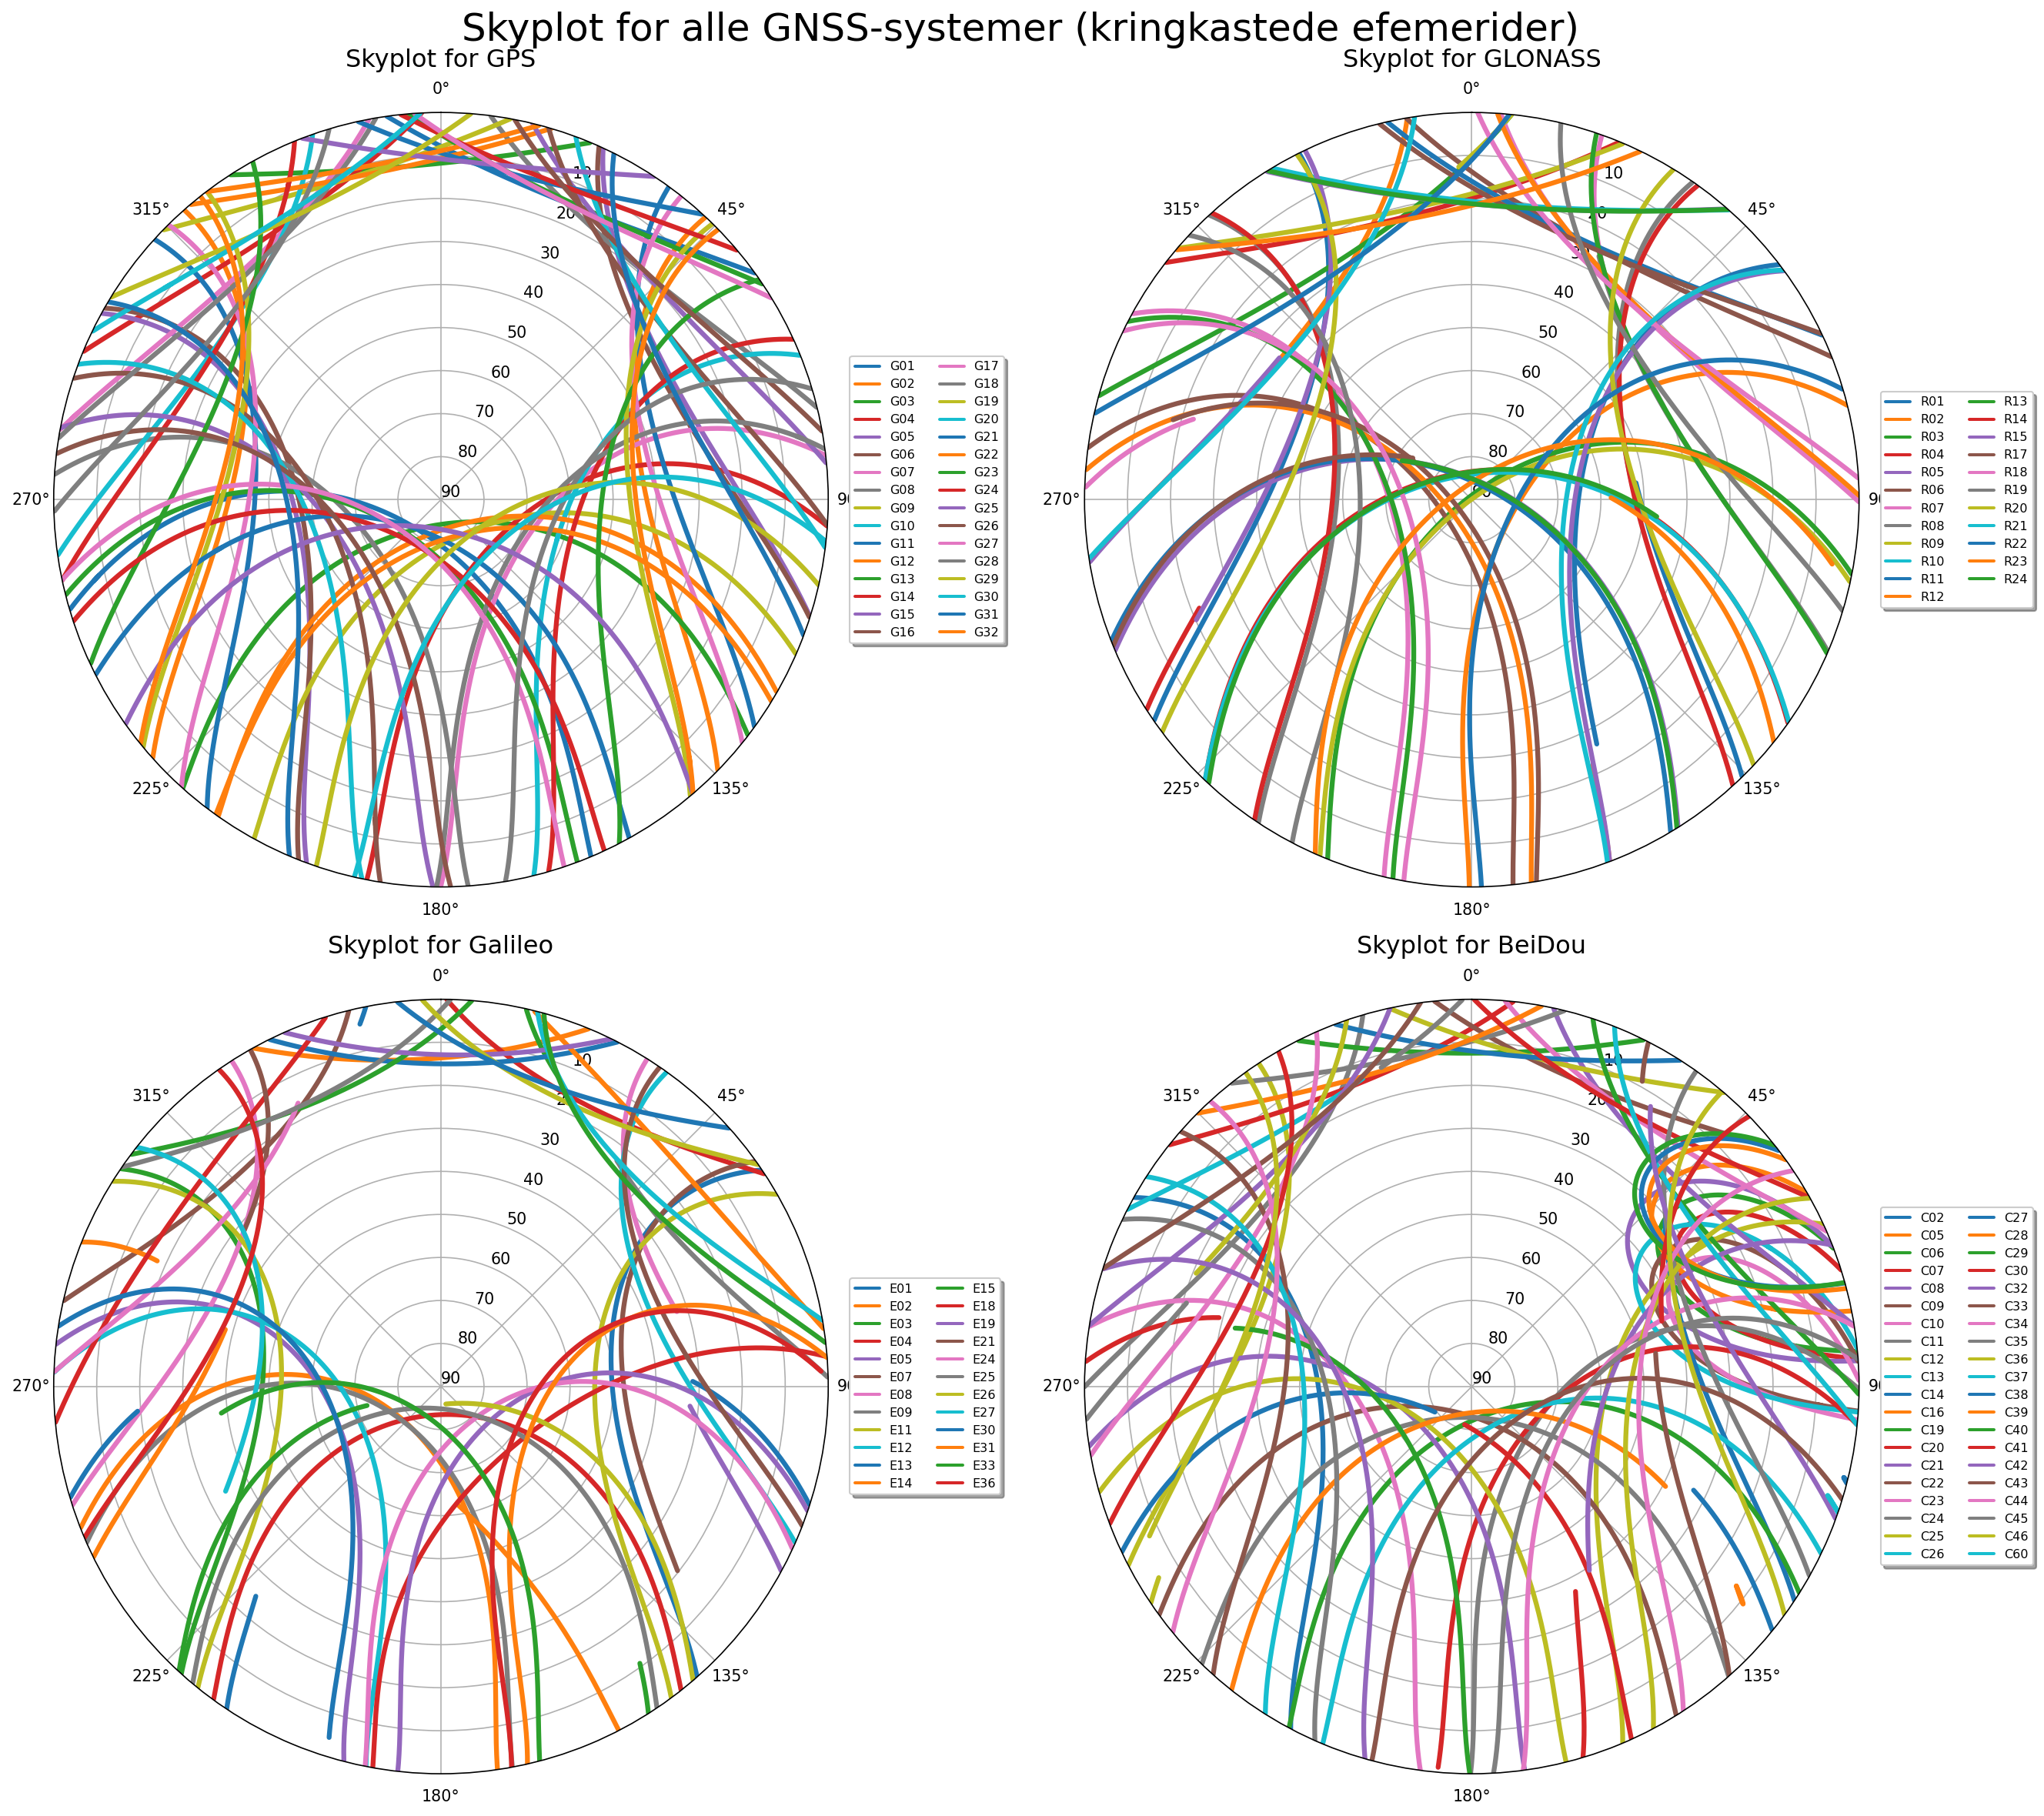

In [21]:
from io import BytesIO
from IPython.display import Image
import matplotlib.pyplot as plt
import gnssmultipath.plot.make_polarplot as polarplot
from pathlib import Path
from gnssmultipath import readRinexObs, SatelliteEphemerisToECEF

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'TestData').is_dir())
rin_obs = repo_root / 'TestData' / 'ObservationFiles' / 'v3' / 'OPEC00NOR_S_20220010000_01D_30S_MO_3.04.rnx'
rin_nav = repo_root / 'TestData' / 'NavigationFiles' / 'v3' / 'BRDC00IGS_R_20220010000_01D_MN.rnx'

# Lese inn observasjonsfila
rinex = readRinexObs(rin_obs)
x_rec, y_rec, z_rec = rinex.approxPosition.flatten().astype(float)
time_epochs, tow = rinex.time_epochs, rinex.time_epochs[:, 1]

# Beregne satellittkoordinater i ECEF for alle systemer og alle epoker, basert på kringkastede efemerider.
converter = SatelliteEphemerisToECEF(rin_nav, x_rec, y_rec, z_rec, desired_systems=['G', 'R', 'E', 'C'])
sat_coord = converter.get_sat_ecef_coordinates(tow, output_format="dict")
angles = converter.compute_satellite_azimut_and_elevation_angle(drop_below_horizon=True) 

gnss_names = {'G': 'GPS', 'R': 'GLONASS', 'E': 'Galileo', 'C': 'BeiDou'}
fig, axes = plt.subplots(2, 2, figsize=(18, 16), dpi=120, subplot_kw={'projection': 'polar'})

for axis, (code, name) in zip(axes.ravel(), gnss_names.items()):
    polarplot.make_skyplot(angles[code]['azimuth'], angles[code]['elevation'], name, None,
                           use_tex=False, save=False, ax=axis)
    
fig.suptitle('Skyplot for alle GNSS-systemer (kringkastede efemerider)', fontsize=24)
fig.tight_layout()
image = BytesIO()
fig.savefig(image, format='png', dpi=150, bbox_inches='tight')
plt.close(fig)
Image(data=image.getvalue(), width=1100)
